# X-LoVoCCS: Summarising the data archive used in the X-LoVoCCS-I paper

## Import statements

In [1]:
from warnings import warn

import pandas as pd
import numpy as np
import json
from matplotlib import pyplot as plt
from astropy.units import Quantity

from xga.products import ExpMap
from xga.imagetools import annular_mask

%matplotlib inline

## Loading data files

Important considerations for this dataset:

* The galaxy clusters investigated in the first X-LoVoCCS publication are a subset (58) of the whole LoVoCCS sample (147). They were originally presented in the second LoVoCCS paper (LoVoCCS-II; [Shenming et al. 2022](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)), and all have LoVoCCS 2D weak-lensing aperture mass maps available.
* As the X-LoVoCCS sample has additional entries in the cases where multiple X-ray components are evident in modern observations (e.g. LoVoCCS-41 becomes LoVoCCS-41**A**, **B**, and **C**), we also load the original LoVoCCS selection sample, where MCXC entries are linked to whole LoVoCCS clusters.

### X-LoVoCCS-I base sample

The general sample file for the X-LoVoCCS-I publication:

In [2]:
xlovoccsI_base = pd.read_csv("../../sample_files/paper_specific_subsamples/X-LoVoCCSI.csv")
xlovoccsI_base.head(6)

,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
3,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44
4,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
5,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44


### LoVoCCS MCXC entries

The subset of the MCXC catalog that constitutes the original LoVoCCS selection: 

In [3]:
lovoccs_mcxc = pd.read_csv("../../sample_files/mcxc_lovoccs.csv")
lovoccs_mcxc.head(6)

,NAME,ALT_NAME,OTHER_NAMES,MCXC_RA,MCXC_DEC,MCXC_REDSHIFT,CATALOG_NAME,SUB_CATALOG_NAME,LINEAR_SCALE_FACTOR,LX_500,...,NOTES,OVERLAP_CAT_1,OVERLAP_CAT_2,OVERLAP_CAT_3,OVERLAP_CAT_4,LX_RATIO_CAT_1,LX_RATIO_CAT_2,LX_RATIO_CAT_3,LX_RATIO_CAT_4,LoVoCCSID
0,MCXC J1558.3+2713,RXC J1558.3+2713,A2142 ...,239.5858,27.2269,0.0894,NORAS/REFLEX,NORAS,1.669,1.067609e+45,...,L,BCS,NaN,NaN,NaN,1.045,NaN,NaN,NaN,0
1,MCXC J1510.9+0543,A2029,A2029 ...,227.7292,5.7200,0.0766,BCS,BCS,1.451,8.726709e+44,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,MCXC J0258.9+1334,RXC J0258.9+1334,A0401 ...,44.7396,13.5794,0.0739,NORAS/REFLEX,NORAS,1.405,6.088643e+44,...,L,BCS,NaN,NaN,NaN,0.880,NaN,NaN,NaN,2
3,MCXC J1348.8+2635,RXC J1348.8+2635,A1795 ...,207.2208,26.5956,0.0622,NORAS/REFLEX,NORAS,1.199,5.478067e+44,...,NaN,BCS,NaN,NaN,NaN,1.197,NaN,NaN,NaN,3
4,MCXC J0041.8-0918,RXC J0041.8-0918,A0085 ...,10.4588,-9.3019,0.0555,NORAS/REFLEX,REFLEX,1.078,5.100085e+44,...,"L,losStr",SGP,NaN,NaN,NaN,0.945,NaN,NaN,NaN,4
5,MCXC J2012.5-5649,RXC J2012.5-5649,A3667 ...,303.1271,-56.8319,0.0556,NORAS/REFLEX,REFLEX,1.080,4.871933e+44,...,"L,losStr",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


### X-LoVoCCS relevant observations index

A set of information produced during the X-LoVoCCS-Data coverage map generation process, linking specific 'parent' LoVoCCS IDs (i.e. as selected from MCXC, prior to some clusters being split into multiple components using modern observations) to unique ObsIDs from a variety of X-ray telescopes:

In [4]:
with open("../../data_notes/rel_obs_for_clusters.json", 'r') as reado:
    xlovoccs_rel_obs = json.load(reado)

# As an example
xlovoccs_rel_obs['LoVoCCS-123']

{'xmm_pointed': ['0861150201',
  '0057740401',
  '0821310101',
  '0030140301',
  '0201780101',
  '0861150301',
  '0030140201',
  '0030140101',
  '0057740301'],
 'chandra': ['4198', '15635', '4403', '10746', '8268', '10745', '15634'],
 'rosat_pointed_pspc': ['RP300093N00', 'RP701155N00', 'RP800374N00'],
 'rosat_all_sky': ['RS932330N00', 'RS932232N00'],
 'swift_xrt': ['00033205005',
  '00033205007',
  '00033205001',
  '00037154019',
  '00033205009',
  '07017525001',
  '07017314001',
  '00033205004',
  '07017508001',
  '00034679001',
  '07017097001',
  '00033205003',
  '00033205008',
  '07017509001',
  '00033205002',
  '03108418001'],
 'asca': ['86016000', '84057000', '86014000', '86015000'],
 'suzaku': ['808107010', '808104010'],
 'erosita_all_sky_de_dr1': ['194120']}

## Counting observations near to X-LoVoCCS-I clusters

The relevant observations dictionary that we loaded in links particular clusters to particular observations by X-ray telescopes - though it is important to recognise that these observations aren't yet guaranteed to be **actually of** the cluster of interest, as they could just be nearby. 

### Relevant observations dataframe

In this case, a Pandas dataframe will be easier to work with than the dictionary that we loaded in - once converted we can filter to select only the clusters relevant to X-LoVoCCS-I - then we can count the number of observations by each telescope possibly connected to each system:

In [5]:
all_rel_obs = pd.DataFrame.from_dict(xlovoccs_rel_obs).T
all_rel_obs.head(3)

,xmm_pointed,chandra,rosat_pointed_pspc,rosat_pointed_hri,rosat_all_sky,swift_xrt,asca,suzaku,nustar_pointed,erosita_all_sky_de_dr1
LoVoCCS-0,"[0111870301, 0112240401, 0694440601, 069444020...","[24490, 23844, 16565, 17168, 7692, 24488, 1228...","[RP800415N00, RP800096N00, RP800551N00, RP1500...","[RH800687N00, RH800640N00]",[RS931239N00],[00089945001],"[81005000, 81004000]","[801055010, 802030010]",NaN,NaN
LoVoCCS-1,"[0744410901, 0822350101, 0551780301, 010992010...","[29418, 25863, 25825, 29438, 10437, 27848, 272...","[RP800275N00, RP800275A01, RP800161N00, RP8002...","[RH800223N00, RH800223A02, RH800223A01, RH8009...",[RS931641N00],"[00036339003, 03111929001, 00035188001, 031119...","[83040010, 81023000, 85061000, 83040020, 85058...","[804024050, 100006010, 804024020, 804024030, 1...","[60401024002, 70660001002, 60801046002]",NaN
LoVoCCS-2,"[0112260201, 0112260101, 0112260401, 092167010...","[27549, 27560, 27562, 10419, 10416, 22882, 272...","[RP800235N00, RP180248N00, RP180250N00, RP1802...","[RH800850A01, RH800823N00, RH800850N00, RH8009...",[RS931508N00],"[07030661001, 00094101002, 07030660001, 070306...","[82009000, 82010000, 82008000]","[801020010, 808005010, 808007010, 808006010]",NaN,NaN


Now we cut it down:

In [6]:
# We construct a list of the 'parent' clusters (i.e. no LoVoCCS-41C or LoVoCCS-93A etc.) - as we had not split
#  the clusters into multiple components at the initial X-ray data acquisition/cleaning stage
lov_parent_names = np.unique(xlovoccsI_base['parent_LoVoCCSID'].apply(lambda x: 'LoVoCCS-'+str(x)))
# And select the rows of the all_rel_obs dataframe that are relevant to them
rel_rel_obs = all_rel_obs.loc[lov_parent_names]
rel_rel_obs.head(3)

,xmm_pointed,chandra,rosat_pointed_pspc,rosat_pointed_hri,rosat_all_sky,swift_xrt,asca,suzaku,nustar_pointed,erosita_all_sky_de_dr1
LoVoCCS-1,"[0744410901, 0822350101, 0551780301, 010992010...","[29418, 25863, 25825, 29438, 10437, 27848, 272...","[RP800275N00, RP800275A01, RP800161N00, RP8002...","[RH800223N00, RH800223A02, RH800223A01, RH8009...",[RS931641N00],"[00036339003, 03111929001, 00035188001, 031119...","[83040010, 81023000, 85061000, 83040020, 85058...","[804024050, 100006010, 804024020, 804024030, 1...","[60401024002, 70660001002, 60801046002]",NaN
LoVoCCS-10,[0203020101],[4185],[RP800353N00],NaN,"[RS931735N00, RS931835N00]","[00049401006, 00049401067, 00049401047, 000494...",[82036000],NaN,[70860004002],"[194093, 197093]"
LoVoCCS-108,NaN,NaN,NaN,NaN,[RS932327N00],NaN,NaN,NaN,NaN,[175123]


### Counting X-ray observations

In [7]:
rel_rel_obs_num = rel_rel_obs.map(lambda x: len(x), na_action='ignore').fillna(0).astype(int)
rel_rel_obs_num

,xmm_pointed,chandra,rosat_pointed_pspc,rosat_pointed_hri,rosat_all_sky,swift_xrt,asca,suzaku,nustar_pointed,erosita_all_sky_de_dr1
LoVoCCS-1,24,59,4,5,1,23,6,11,3,0
LoVoCCS-10,1,1,1,0,2,78,1,0,1,2
LoVoCCS-108,0,0,0,0,1,0,0,0,0,1
LoVoCCS-11,14,10,5,4,1,25,1,1,1,2
LoVoCCS-119,3,3,0,0,1,0,0,0,0,2
LoVoCCS-12,2,1,1,1,1,4,3,1,1,2
LoVoCCS-121,3,1,2,1,3,4,1,0,0,3
LoVoCCS-122,0,0,0,0,2,0,0,0,0,1
LoVoCCS-123,9,7,3,0,2,16,4,2,0,1
LoVoCCS-13,4,8,2,2,1,4,1,9,1,2


### How many observations from each telescope are there in total?

Here we will find out the number of **unique** observations by each telescope that are relevant to one or more of the clusters in the X-LoVoCCS-I sample:

In [8]:
rel_rel_obs.apply(lambda x: len(np.unique(x.dropna().sum())))

xmm_pointed               222
chandra                   260
rosat_pointed_pspc         58
rosat_pointed_hri          49
rosat_all_sky              69
swift_xrt                 432
asca                       46
suzaku                     61
nustar_pointed             18
erosita_all_sky_de_dr1     55
dtype: int64

### What are the ObsIDs of the possibly-relevant XMM observations?

Here we include a combined list of all the relevant observations, if you are interested in specifically associating ObsIDs to LoVoCCS clusters, please check the "rel_obs_for_clusters.json" file stored in the top-level "data_notes" directory (loaded in at the top of this notebook):

In [9]:
all_xmm_ois = rel_rel_obs.apply(lambda x: np.unique(x.dropna().sum()))['xmm_pointed']
all_xmm_ois

array(['0010420201', '0018741001', '0030140101', '0030140201',
       '0030140301', '0042341101', '0057740301', '0057740401',
       '0065140101', '0065140201', '0086950201', '0093200101',
       '0103860601', '0105260101', '0105260201', '0105260301',
       '0105260401', '0105260501', '0105260601', '0105260701',
       '0105260801', '0105260901', '0105261001', '0105261101',
       '0105262001', '0105262101', '0105262201', '0105262501',
       '0105660101', '0107260101', '0108460201', '0108460301',
       '0109920101', '0109920301', '0109930101', '0109950101',
       '0109950201', '0109980301', '0109980501', '0111270201',
       '0112240101', '0112240301', '0112260101', '0112260201',
       '0112260301', '0112260401', '0112850201', '0112950301',
       '0112950401', '0132721301', '0136740101', '0136740201',
       '0147040101', '0147330101', '0149670101', '0149670301',
       '0201780101', '0201900401', '0201900501', '0201901601',
       '0201902001', '0201902101', '0201902701', '02030

### Exposure times at the start coordinates

Importantly, where we have previously dealt with the 'parent' clusters, here we will identify exposure times at start coordinates for _all_ the X-LoVoCCS clusters (i.e. with multiple parent clusters split into multiple components). This is valid because the ObsIDs in a wide area around the parent cluster coordinate where associated with the cluster, and if a parent cluster is split into sub-components they will necessarily be nearby.

**Note that this part of the notebook cannot be re-run without having already acquired and processed the relevant XMM data**

In [10]:
xmm_ex_pth = "../../data/archives/LoVoCCS/processed_data/xmm_pointed/{oi}/images/"\
             "obsid{oi}-inst{i}-subexpALL-en0.5_2.0keV-expmap.fits"

#### Loading the exposure maps

In [11]:
all_ex_maps = {oi: {} for oi in all_xmm_ois}
for obs_id in all_xmm_ois:
    for inst in ['M1', 'M2', 'PN']:
        try:
            cur_ex_pth = xmm_ex_pth.format(oi=obs_id, i=inst)
            cur_ex = ExpMap(cur_ex_pth, obs_id, inst, '', '', '', Quantity(0.5, 'keV'), Quantity(2.0, 'keV'))
            # This will make sure the class checks that the file exists
            cur_ex.header
            all_ex_maps[obs_id][inst] = cur_ex
        except FileNotFoundError:
            print(obs_id, inst)

0109920301 PN
0109980501 PN
0132721301 M2
0132721301 PN
0201901601 PN
0785130501 PN
0823650501 PN


#### Exposure times at start coordinates

In [12]:
rel_exp_times = {}
for row_ind, row in xlovoccsI_base.iterrows():
    # The start coordinate of the current entry (including sub-components like 41A)
    start_coord = Quantity(row[['start_ra', 'start_dec']].values, 'deg')
    # ObsIDs associated with the PARENT LoVoCCSID - e.g. 41
    cur_poss_rel_ois = rel_rel_obs.loc['LoVoCCS-'+str(row['parent_LoVoCCSID'])]['xmm_pointed']

    if not isinstance(cur_poss_rel_ois, list):
        warn("LoVoCCS-"+row['LoVoCCSID']+" does not have associated XMM ObsIDs", stacklevel=0)
        continue
    
    # Iterating through the relevant ObsIDs and grabbing the relevant exposure maps
    cur_ex_maps = [cur_ex for obs_id in cur_poss_rel_ois for cur_ex in all_ex_maps[obs_id].values()]
    
    # This is where we'll store the relevant exposure times at the start coordinate
    cur_rel_exp_times = {}
    # Shame we can't do this in a list comprehension as well, but we need to be able to catch
    #  any errors caused by the start coordinate being off of the exposure map
    for cur_ex in cur_ex_maps:
        try:
            cur_rel_exp_times[cur_ex.obs_id+cur_ex.instrument] = cur_ex.get_exp(start_coord)
        except ValueError:
            continue
            print(row['LoVoCCSID'])
            print(cur_ex.obs_id, cur_ex.instrument)

    # Validity check - ensuring that instrument level exposure times are accurate and not falsely zero
    #  because of chip gaps in different detectors.
    # The initial conditions of there being a zero exposure on one instrument and not on others could be
    #  triggered for many reasons (MOS1 with its broken chips, one instrument being in an unusual mode, etc.)
    #  but we are still going to check
    for cur_obs_id in cur_poss_rel_ois:
        # Read out exposure times with IDs that contain the current ObsID
        rel_exs = Quantity([cur_time for cur_id, cur_time in cur_rel_exp_times.items() if cur_obs_id in cur_id])
        # Also their IDs are read into an array as well
        rel_ex_ids = np.array([cur_id for cur_id, cur_time in cur_rel_exp_times.items() if cur_obs_id in cur_id])
        
        # Don't need to keep going if we actually have no times for that ObsID
        if len(rel_exs) == 0:
            continue

        # Are any exposure times zero?
        zero_exp = (rel_exs.value == 0)
        # And more importantly, are there zero exposure times when other times associated with that ObsID are non-zero?
        if zero_exp.any() and not zero_exp.all():
            for rel_zero_ex_id in rel_ex_ids[zero_exp]:
                # Grabbing the relevant exposure map object again
                cur_rel_exmap = all_ex_maps[cur_obs_id][rel_zero_ex_id.split(cur_obs_id)[-1]]
                # Get the pixel coordinate
                cur_pix_coord = cur_rel_exmap.coord_conv(start_coord, 'pix')

                # Make a mask to select pixels within an 8-pixel (arbitrarily chosen) radius circle of the start coord
                arnd_coord_msk = annular_mask(cur_pix_coord, np.array([0]), np.array([8]), cur_rel_exmap.shape)
                # Then we select the highest exposure of those pixels to act as the exposure at the start coordinate
                new_exp = Quantity(cur_rel_exmap.data[arnd_coord_msk].max(), cur_rel_exmap.data_unit)
                cur_rel_exp_times[rel_zero_ex_id] = new_exp

    # Adding the exposure times for this cluster to the overall dictionary for later
    rel_exp_times["LoVoCCS-"+str(row['LoVoCCSID'])] = cur_rel_exp_times

/tmp/ipykernel_1971804/4123448182.py:9: UserWarning: LoVoCCS-55 does not have associated XMM ObsIDs
  warn("LoVoCCS-"+row['LoVoCCSID']+" does not have associated XMM ObsIDs", stacklevel=0)
/tmp/ipykernel_1971804/4123448182.py:9: UserWarning: LoVoCCS-108 does not have associated XMM ObsIDs
  warn("LoVoCCS-"+row['LoVoCCSID']+" does not have associated XMM ObsIDs", stacklevel=0)
/tmp/ipykernel_1971804/4123448182.py:9: UserWarning: LoVoCCS-122 does not have associated XMM ObsIDs
  warn("LoVoCCS-"+row['LoVoCCSID']+" does not have associated XMM ObsIDs", stacklevel=0)


#### Various measures of exposure per cluster

In [13]:
# One total (every ObsID every instrument) exposure for each cluster
tot_exps = {n: {} for n in rel_exp_times}
# Total exposures for PN, M1, and M2 separately
tot_pn_exps = {n: {} for n in rel_exp_times}
tot_m1_exps = {n: {} for n in rel_exp_times}
tot_m2_exps = {n: {} for n in rel_exp_times}
# Maximum exposure time of an individual observation (i.e. PN of <obsid>, or MOS2 of <anotherobsid>)
max_indiv_exps = {n: {} for n in rel_exp_times}

for name, cur_exp_times in rel_exp_times.items():
    # Just sum up every exposure time for a given cluster
    tot_exps[name] = sum(list(cur_exp_times.values()))
    print(name, 'total exposure -', tot_exps[name].round(3))

    # Select the times that have IDs (ObsID + instrument) with the relevant instrument's name in them - then sum them
    tot_pn_exps[name] = Quantity(sum([cur_time for cur_id, cur_time in cur_exp_times.items() if 'PN' in cur_id]), 's')
    tot_m1_exps[name] = Quantity(sum([cur_time for cur_id, cur_time in cur_exp_times.items() if 'M1' in cur_id]), 's')
    tot_m2_exps[name] = Quantity(sum([cur_time for cur_id, cur_time in cur_exp_times.items() if 'M2' in cur_id]), 's')

    # Now just find the longest individual (i.e. for a particular instrument of a particular ObsID) exposure and its corresponding ID
    max_exp_id = max(cur_exp_times, key=cur_exp_times.get)
    max_indiv_exps[name]['id'] = max_exp_id
    max_indiv_exps[name]['exp'] = cur_exp_times[max_exp_id]

LoVoCCS-1 total exposure - 371331.13 s
LoVoCCS-2 total exposure - 32201.209 s
LoVoCCS-4A total exposure - 570005.062 s
LoVoCCS-4B total exposure - 184881.54 s
LoVoCCS-5 total exposure - 218901.502 s
LoVoCCS-7 total exposure - 73501.978 s
LoVoCCS-9 total exposure - 824973.944 s
LoVoCCS-10 total exposure - 23358.343 s
LoVoCCS-11 total exposure - 235352.617 s
LoVoCCS-12 total exposure - 52705.029 s
LoVoCCS-13 total exposure - 497533.26 s
LoVoCCS-14 total exposure - 27622.755 s
LoVoCCS-15 total exposure - 329829.362 s
LoVoCCS-18 total exposure - 96778.381 s
LoVoCCS-21 total exposure - 113248.09 s
LoVoCCS-22 total exposure - 28700.053 s
LoVoCCS-24 total exposure - 79504.031 s
LoVoCCS-26 total exposure - 31347.47 s
LoVoCCS-27 total exposure - 53359.801 s
LoVoCCS-28 total exposure - 62909.828 s
LoVoCCS-29 total exposure - 63311.207 s
LoVoCCS-30 total exposure - 1078070.808 s
LoVoCCS-31 total exposure - 36436.545 s
LoVoCCS-33 total exposure - 0.0 s
LoVoCCS-35 total exposure - 69004.486 s
LoVoC

We save the total exposures to disk:

In [14]:
with open("../../data_notes/total_xmm_exposures.json", 'w') as exposo:
    save_tot_exps = {n: str(e.to('ks').round(3)) for n, e in tot_exps.items()}
    json.dump(save_tot_exps, exposo)

#### Visualizing the exposure times

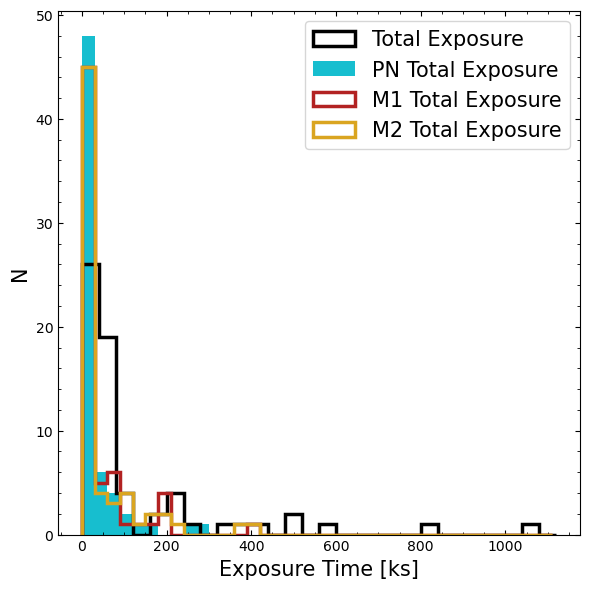

In [15]:
# These bins are for the total exposure times
#  Step size in ks
tot_step_size = 40
tot_bins = np.arange(0, 1100+tot_step_size, tot_step_size)

# For the other exposures
step_size = 30
bins = np.arange(0, 1100+step_size, step_size)

plt.figure(figsize=(6, 6))
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.hist(Quantity(list(tot_exps.values())).to('ks').value, bins=tot_bins, histtype='step', lw=2.5, color='black', 
         linestyle='solid', label='Total Exposure')
plt.hist(Quantity(list(tot_pn_exps.values())).to('ks').value, bins=bins, histtype='stepfilled', lw=2.5, color='tab:cyan', 
         linestyle='solid', label='PN Total Exposure')
plt.hist(Quantity(list(tot_m1_exps.values())).to('ks').value, bins=bins, histtype='step', lw=2.5, color='firebrick', 
         linestyle='solid', label='M1 Total Exposure')
plt.hist(Quantity(list(tot_m2_exps.values())).to('ks').value, bins=bins, histtype='step', lw=2.5, color='goldenrod', 
         linestyle='solid', label='M2 Total Exposure')

plt.xlabel("Exposure Time [ks]", fontsize=15)
plt.ylabel("N", fontsize=15)

plt.legend(fontsize=15)
plt.tight_layout()
plt.savefig("../../outputs/figures/X-LoVoCCS-I_xmm_exposure_hist.pdf")
plt.show()